<a href="https://colab.research.google.com/github/haribharadwaj/notebooks/blob/main/BasicEvokedResponse.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Basic Evoked Response Analysis

## Auditory steady-state response example

**Stimulus**: 500 Hz tone, 1 second long, amplitude modulated at 40 Hz, presented at 72 dB SPL

**Presentation**: Presented in both polarities (to attenuate stimulus artifact), 200 repetitions per polarity, inter-stimulus interval drawn uniformly between 100 and 500 ms (to attenuate steady background noise sources).

**EEG Triggers**: Coded as 1 or 2 for two polarities


In [1]:
# Installations

!pip -q install git+https://github.com/haribharadwaj/mne-python
!pip -q install git+https://github.com/SNAPlabgroup/ANLffr.git

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done


## Download the data from Dropbox to the Colab server
We will use `wget`. Downloaded files on the Colab server are available in `/content`. We will make another directory within there for our data called `eegdata`. So the files will be in `/content/eegdata/`.

In [2]:
!mkdir eegdata
!wget -q --show-progress -O eegdata/EEG1.bdf https://bit.ly/EEGgroup_ASSR1
!wget -q --show-progress -O eegdata/EEG2.bdf https://bit.ly/EEGgroup_ASSR2

eegdata/EEG1.bdf    100%[===================>]   1022M  93.2MB/s    in 14s     
eegdata/EEG2.bdf    100%[===================>]  42.29M  82.8MB/s    in 0.5s    


## Read file 1 into MNE using ANLffr's helper functions

In [4]:
from anlffr.helper import biosemi2mne as bs
import mne

In [5]:
fpath = '/content/eegdata/'

raw, eves = bs.importbdf(fpath + 'EEG1.bdf')

Extracting BDF parameters from /content/eegdata/EEG1.bdf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 8716287  =      0.000 ...   532.000 secs...
Re-referencing data to: EXG1 EXG2EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.
Finding events on: Status
Trigger channel Status has a non-zero initial value of 130816 (consider using initial_event=True to detect this event)
388 events found on stim channel Status
Event IDs: [  1   2 253]


In [6]:
eves

array([[   9930,       0,     253],
       [  51033,       0,       1],
       [  72999,       0,       2],
       ...,
       [8653752,       0,       1],
       [8678463,       0,       2],
       [8702924,       0,       1]])

In [7]:
raw

<RawBDF | EEG1.bdf, 41 x 8716288 (532.0 s), ~2.66 GiB, data loaded>

Using matplotlib as 2D backend.


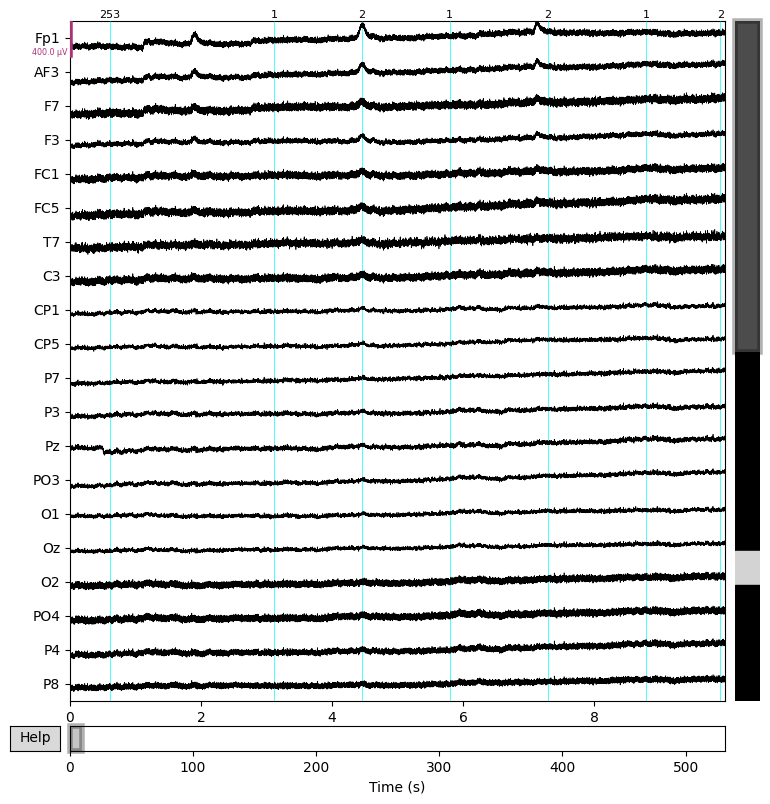

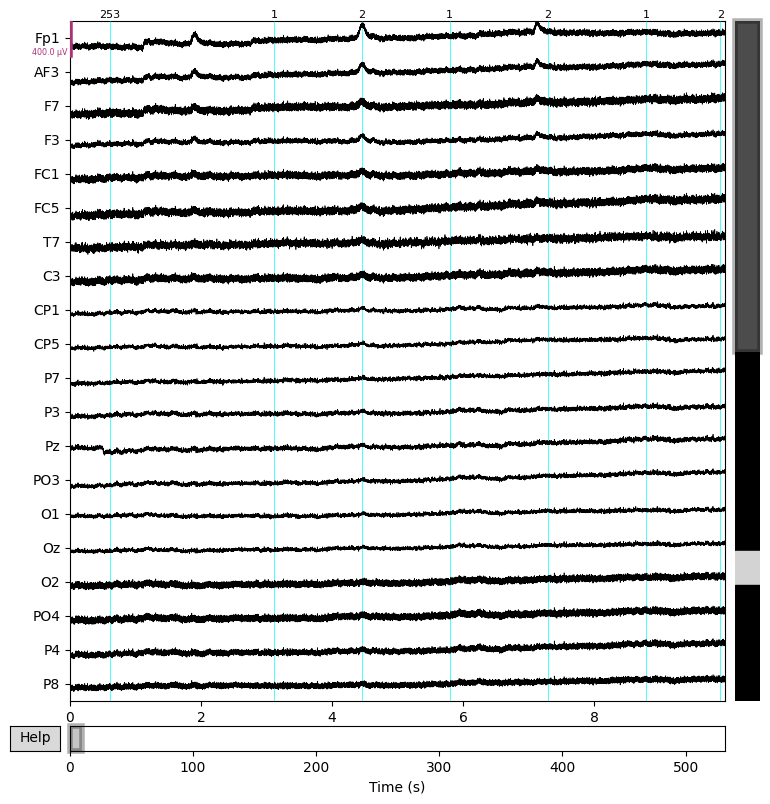

In [8]:
raw.plot(events=eves, scalings=dict(eeg=200e-6))

In [9]:
fmin = 1.5
fmax = 50
raw.filter(l_freq=fmin, h_freq=fmax)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1.5 - 50 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.50
- Lower transition bandwidth: 1.50 Hz (-6 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 50.00 Hz
- Upper transition bandwidth: 12.50 Hz (-6 dB cutoff frequency: 56.25 Hz)
- Filter length: 36045 samples (2.200 s)



<RawBDF | EEG1.bdf, 41 x 8716288 (532.0 s), ~2.66 GiB, data loaded>

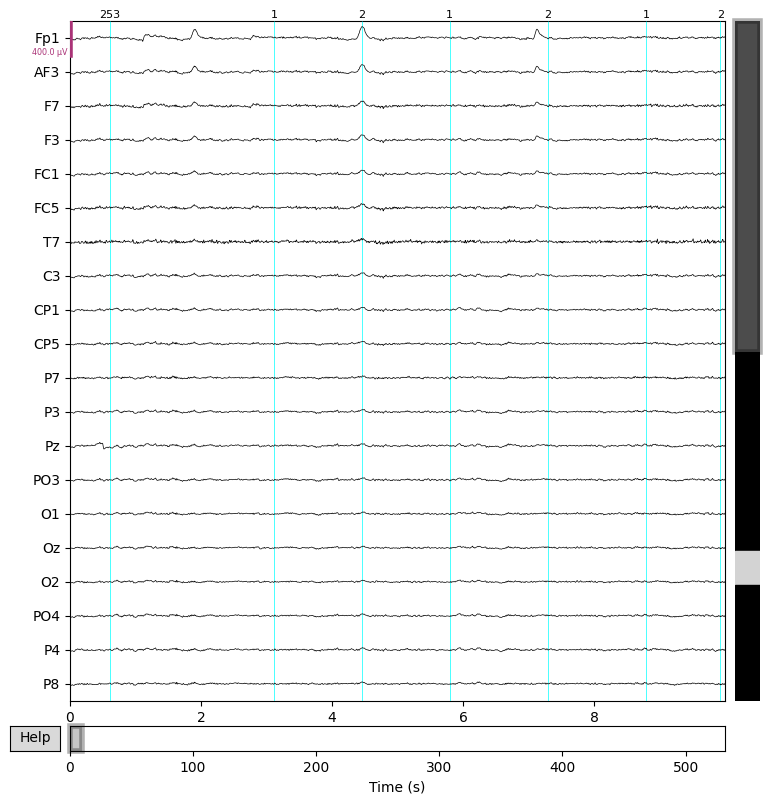

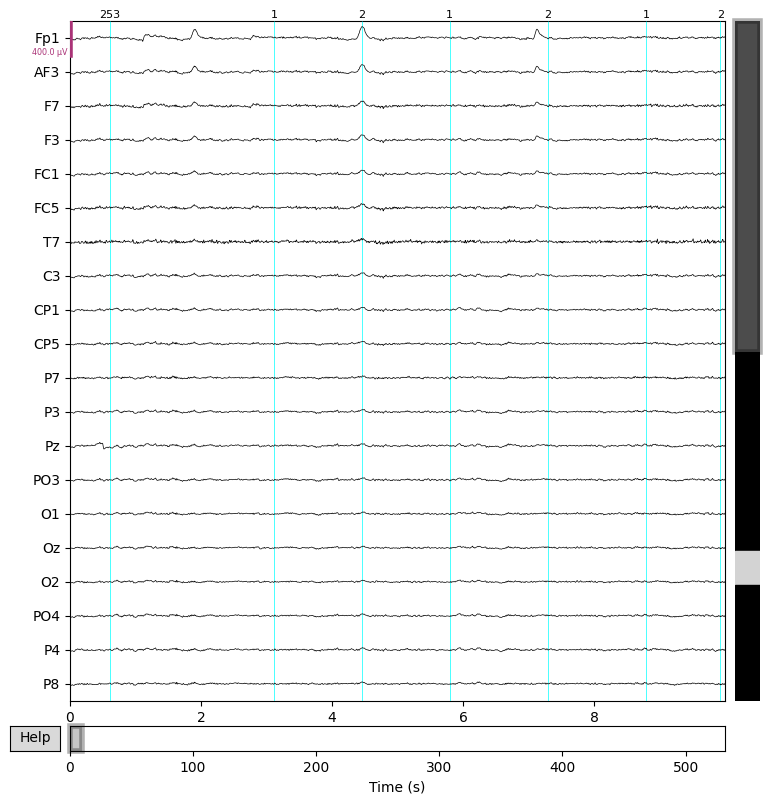

In [10]:
raw.plot(events=eves, scalings=dict(eeg=200e-6))

## Epoching
Epoching involves segmenting chunks of raw data time locked to events of interest. Here, we will epoch the data starting at `tmin=-0.2` around each event and extending up to `tmax=1.5`. This would include a baseline period spanning `bmin=-0.2` to `bmax=0.`.

In [12]:
epochs = mne.Epochs(raw, eves, event_id=[1, 2],
                    tmin=-0.2, tmax=1.5, baseline=(-0.2, 0.),
                    reject=dict(eeg=150e6))

Not setting metadata
387 matching events found
Applying baseline correction (mode: mean)
0 projection items activated


In [13]:
epochs

<Epochs | 387 events (good & bad), -0.2 – 1.5 s (baseline -0.2 – 0 s), ~50 KiB, data not loaded,
 '1': 194
 '2': 193>

## Averaging
The basic evoked response is just the time-locked average response across the epochs.

In [14]:
evoked = epochs.average()

In [15]:
evoked

<Evoked | '0.50 × 1 + 0.50 × 2' (average, N=386), -0.20001 – 1.5 s, baseline -0.2 – 0 s, 34 ch, ~7.3 MiB>

/tmp/ipython-input-723394986.py:1: RuntimeWarning: Only 6 head digitization points of the specified kind ("extra",), fitting may be inaccurate
  evoked.plot()
/tmp/ipython-input-723394986.py:1: RuntimeWarning: Estimated head radius (0.2 cm) is below the 3rd percentile for infant head size.
  evoked.plot()


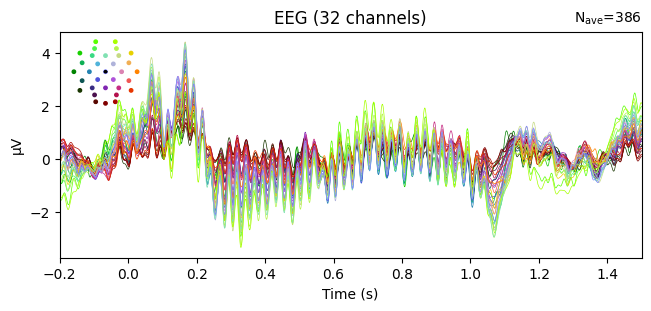

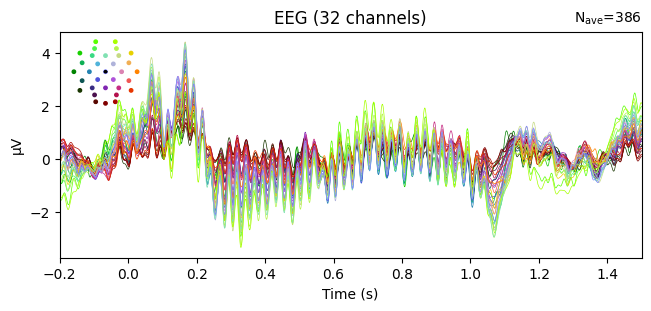

In [16]:
evoked.plot()

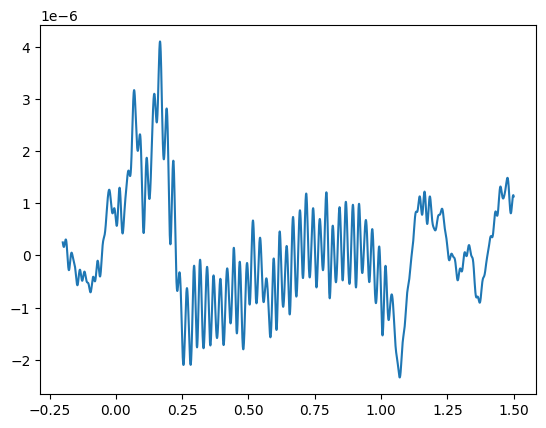

In [19]:
t = evoked.times
x = evoked.data
channel_of_interest = 31
y = x[channel_of_interest, :]
import pylab as pl

pl.plot(t, y)

/tmp/ipython-input-2717457832.py:1: RuntimeWarning: Only 6 head digitization points of the specified kind ("extra",), fitting may be inaccurate
  evoked.plot_topomap()
/tmp/ipython-input-2717457832.py:1: RuntimeWarning: Estimated head radius (0.2 cm) is below the 3rd percentile for infant head size.
  evoked.plot_topomap()
/tmp/ipython-input-2717457832.py:1: RuntimeWarning: Only 6 head digitization points of the specified kind ("extra",), fitting may be inaccurate
  evoked.plot_topomap()
/tmp/ipython-input-2717457832.py:1: RuntimeWarning: Estimated head radius (0.2 cm) is below the 3rd percentile for infant head size.
  evoked.plot_topomap()


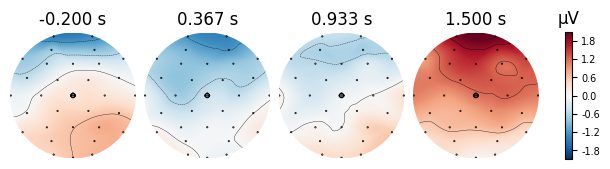

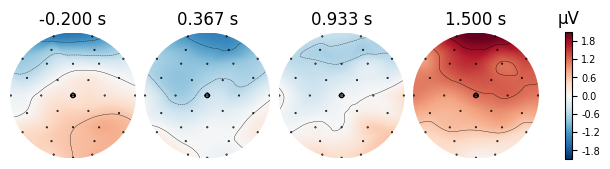

In [21]:
evoked.plot_topomap()

In [23]:
S = evoked.compute_psd(method='multitaper', tmin=0., tmax=1.1, fmin=10., fmax=50., bandwidth=1.)

    Using multitaper spectrum estimation with 1 DPSS windows


/tmp/ipython-input-538498528.py:1: RuntimeWarning: Could not properly use low_bias, keeping lowest-bias taper
  S = evoked.compute_psd(method='multitaper', tmin=0., tmax=1.1, fmin=10., fmax=50., bandwidth=1.)


Plotting power spectral density (dB=False).


/tmp/ipython-input-1576261350.py:1: RuntimeWarning: Only 6 head digitization points of the specified kind ("extra",), fitting may be inaccurate
  S.plot(dB=False)
/tmp/ipython-input-1576261350.py:1: RuntimeWarning: Estimated head radius (0.2 cm) is below the 3rd percentile for infant head size.
  S.plot(dB=False)


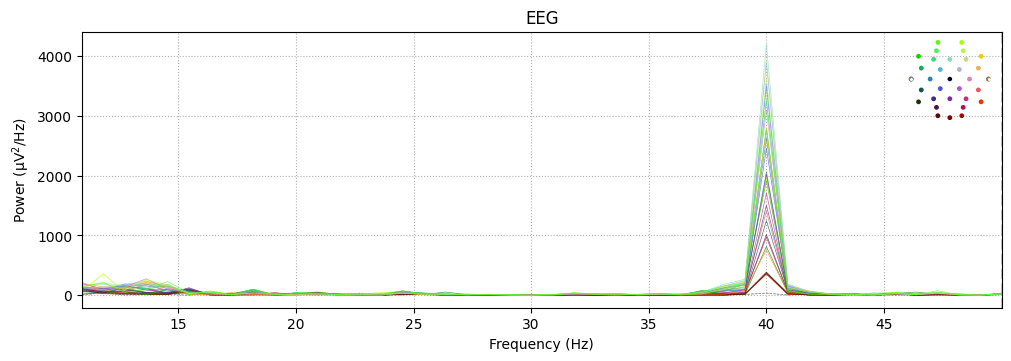

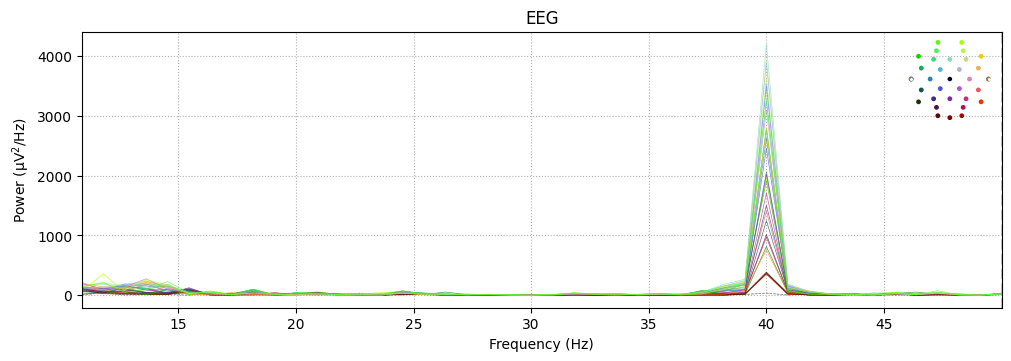

In [25]:
S.plot(dB=False)

/tmp/ipython-input-2493790116.py:1: RuntimeWarning: Only 6 head digitization points of the specified kind ("extra",), fitting may be inaccurate
  S.plot_topomap(bands=dict(ASSR=40.))
/tmp/ipython-input-2493790116.py:1: RuntimeWarning: Estimated head radius (0.2 cm) is below the 3rd percentile for infant head size.
  S.plot_topomap(bands=dict(ASSR=40.))
/tmp/ipython-input-2493790116.py:1: RuntimeWarning: Only 6 head digitization points of the specified kind ("extra",), fitting may be inaccurate
  S.plot_topomap(bands=dict(ASSR=40.))
/tmp/ipython-input-2493790116.py:1: RuntimeWarning: Estimated head radius (0.2 cm) is below the 3rd percentile for infant head size.
  S.plot_topomap(bands=dict(ASSR=40.))


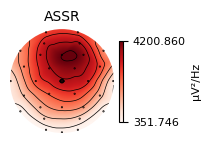

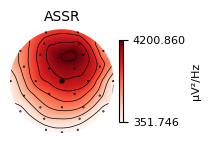

In [29]:
S.plot_topomap(bands=dict(ASSR=40.))

## Using Signal-space projection (SSP) to suppress blink artifacts


In [34]:
from anlffr.preproc import find_blinks
from mne.preprocessing.ssp import compute_proj_epochs

blinks = find_blinks(raw, ch_name=['Fp1', ])
epochs_blinks = mne.Epochs(raw, blinks, 998, tmin=-0.25,
                          tmax=0.25, proj=True,
                          baseline=(-0.25, 0),
                          reject=dict(eeg=1000e-6))
blink_projs = compute_proj_epochs(epochs_blinks, n_eeg=2,
                                  verbose='DEBUG')
raw.add_proj(blink_projs)

Setting up band-pass filter from 0.5 - 10 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.15 Hz (-6 dB cutoff frequency: 0.42 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 2.50 Hz (-6 dB cutoff frequency: 11.25 Hz)
- Filter length: 360449 samples (22.000 s)

Not setting metadata
84 matching events found
Applying baseline correction (mode: mean)
Created an SSP operator (subspace dimension = 1)
1 projection items activated
Got 1 parallel jobs after requesting None
    Getting epoch for 27131-35324
    Getting epoch for 69016-77209
    Getting epoch for 112799-120992
    Getting epoch for 169514-177707
    Getting epoch for 196564-204757
    Getting epoch for 282108-290301
    Getting epoch for 335377-343570
    Getting epoch for

<RawBDF | EEG1.bdf, 41 x 8716288 (532.0 s), ~2.66 GiB, data loaded>

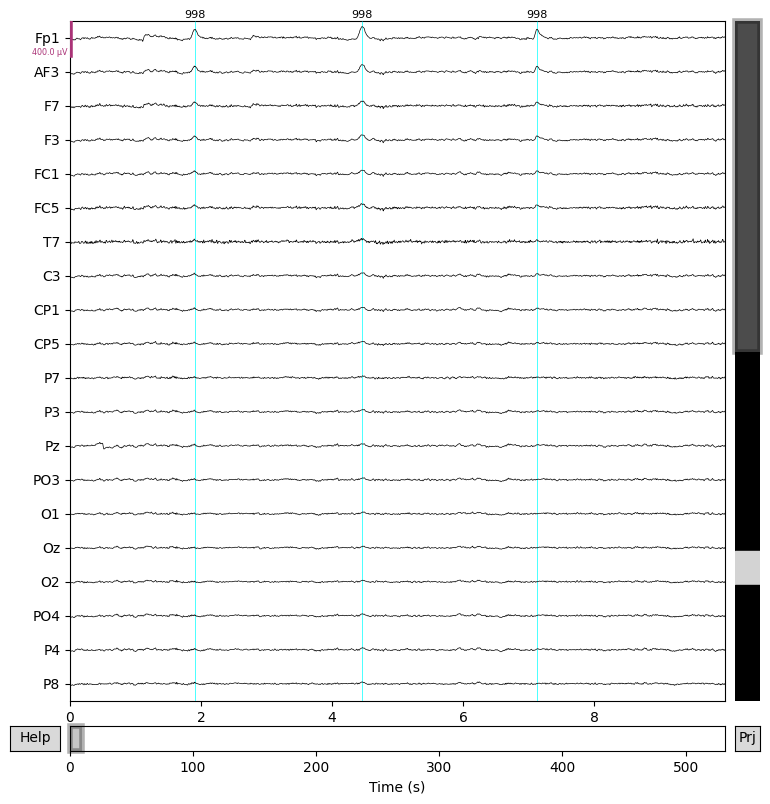

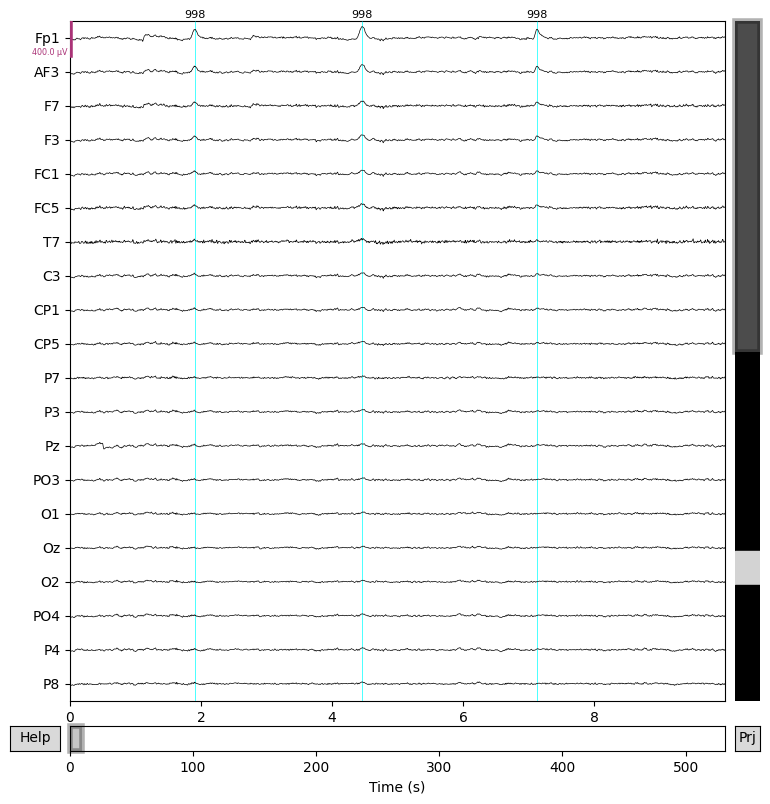

In [31]:
raw.plot(events=blinks, scalings=dict(eeg=200e-6), proj=False)

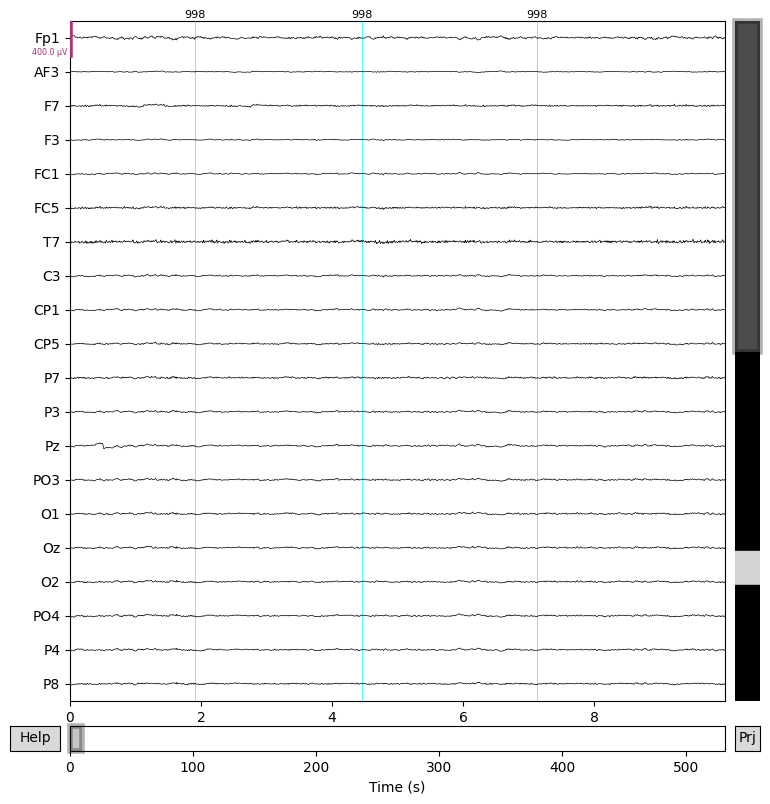

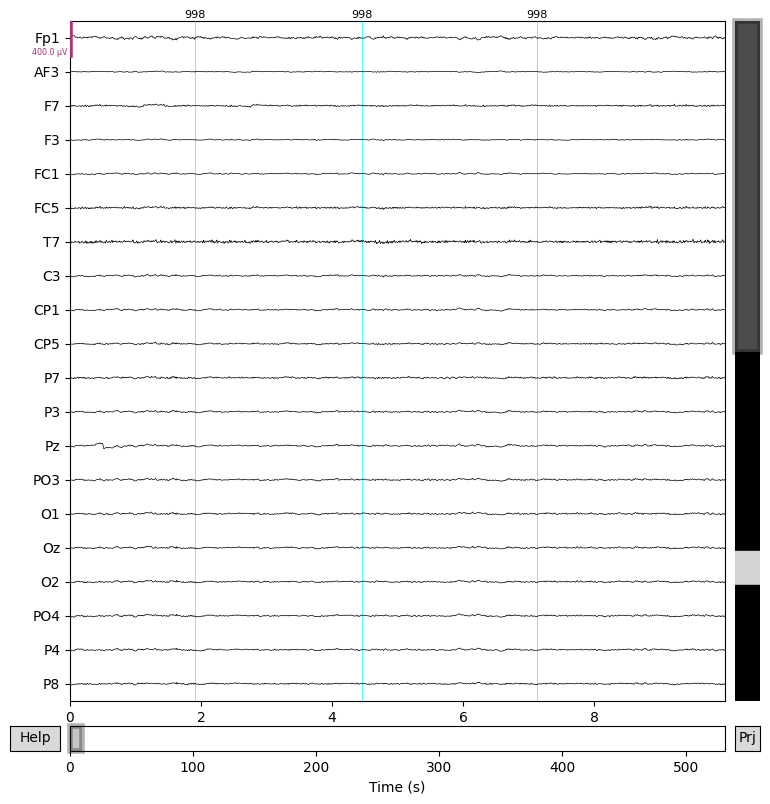

In [32]:
raw.plot(events=blinks, scalings=dict(eeg=200e-6), proj=True)

/tmp/ipython-input-258469152.py:1: RuntimeWarning: Only 6 head digitization points of the specified kind ("extra",), fitting may be inaccurate
  raw.plot_projs_topomap()
/tmp/ipython-input-258469152.py:1: RuntimeWarning: Estimated head radius (0.2 cm) is below the 3rd percentile for infant head size.
  raw.plot_projs_topomap()
/tmp/ipython-input-258469152.py:1: RuntimeWarning: Only 6 head digitization points of the specified kind ("extra",), fitting may be inaccurate
  raw.plot_projs_topomap()
/tmp/ipython-input-258469152.py:1: RuntimeWarning: Estimated head radius (0.2 cm) is below the 3rd percentile for infant head size.
  raw.plot_projs_topomap()


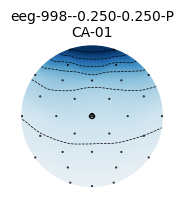

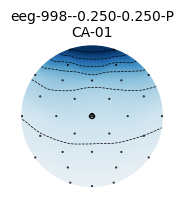

In [33]:
raw.plot_projs_topomap()

/tmp/ipython-input-258469152.py:1: RuntimeWarning: Only 6 head digitization points of the specified kind ("extra",), fitting may be inaccurate
  raw.plot_projs_topomap()
/tmp/ipython-input-258469152.py:1: RuntimeWarning: Estimated head radius (0.2 cm) is below the 3rd percentile for infant head size.
  raw.plot_projs_topomap()
/tmp/ipython-input-258469152.py:1: RuntimeWarning: Only 6 head digitization points of the specified kind ("extra",), fitting may be inaccurate
  raw.plot_projs_topomap()
/tmp/ipython-input-258469152.py:1: RuntimeWarning: Estimated head radius (0.2 cm) is below the 3rd percentile for infant head size.
  raw.plot_projs_topomap()
/tmp/ipython-input-258469152.py:1: RuntimeWarning: Only 6 head digitization points of the specified kind ("extra",), fitting may be inaccurate
  raw.plot_projs_topomap()
/tmp/ipython-input-258469152.py:1: RuntimeWarning: Estimated head radius (0.2 cm) is below the 3rd percentile for infant head size.
  raw.plot_projs_topomap()
/tmp/ipython-

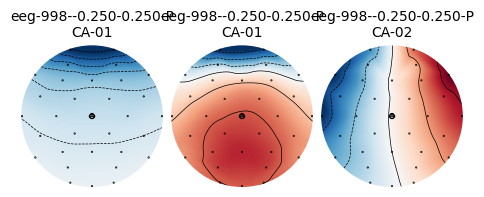

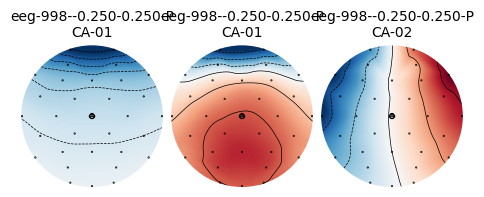

In [35]:
raw.plot_projs_topomap()